In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# makes all plots interactive
# this automatically displays all plots, even if we don't have plt.show()
%matplotlib widget

# 0. Process Data

In [3]:
import sys
sys.path.insert(0, '..')  # Go up from notebooks/ to project root

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.process_data import process_data_all
from src.plot import plot_gradients

In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [6]:
BASE_DIR = Path('../data/experiment-04')
exp_dirs = sorted([d for d in BASE_DIR.iterdir() if d.is_dir() and '.ipynb' not in str(d)])

BASE_DIR = Path('../data/experiment-05')
exp_dirs += sorted([d for d in BASE_DIR.iterdir() if d.is_dir() and '.ipynb' not in str(d)])

In [7]:
# todo: why is 0 here?
canonical_mode_freqs = [53.88888888888889, 85.0, 113.05555555555556, 151.38888888888889, 196.94444444444446, 271.6666666666667, 302.77777777777777, 331.11111111111114, 363.0555555555556]

data = process_data_all(exp_dirs, canonical_mode_freqs=canonical_mode_freqs)
list(data.values())[0].keys()

Loaded 80 experiments


100%|██████████| 80/80 [00:14<00:00,  5.37it/s]


dict_keys(['object', 'x_position', 'y_position', 'position_xy', 'position_idx', 'duplicate_idx', 'fs', 'path', 'shifts_raw', 'time', 'img_path', 'shifts', 'fft_vals', 'freqs', 'mode_freqs', 'mode_freqs_idx', 'mode_fft_vals', 'synced_fft_vals', 'synced_mode_fft_vals', 'synced_fft_gradients', 'mode_fft_gradients', 'synced_mode_fft_gradients'])

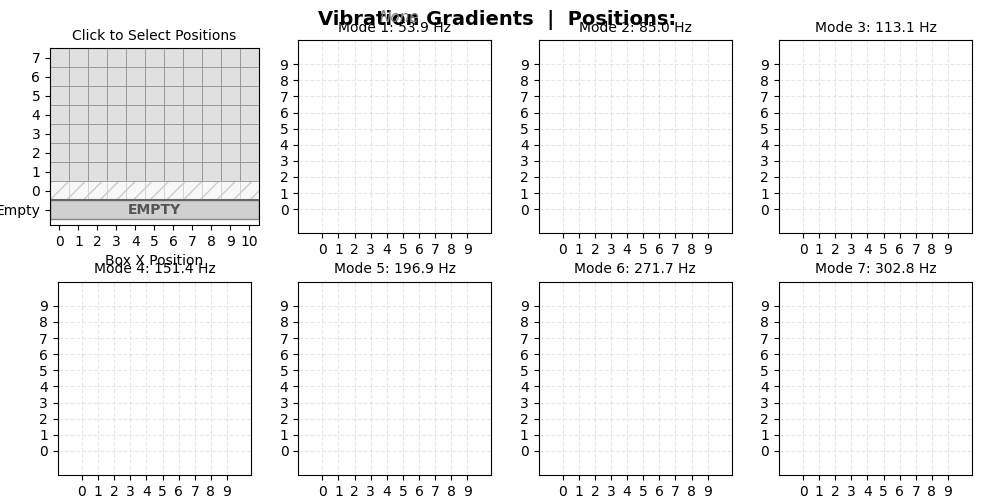

In [8]:
fig = plot_gradients(data, n_rows=2, n_cols=4)
plt.show()

# 0.5 Save Data as Tensors

In [17]:
import json
import torch

# Create output directory
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

# Stack FFT values into tensor (n_samples, n_lasers, n_freqs, 2)
X = torch.from_numpy(np.stack([np.abs(d['fft_vals']) for d in data.values()])).float()
x_labels = torch.tensor([d['x_position'] for d in data.values()])
y_labels = torch.tensor([d['y_position'] for d in data.values()])

# Collect image paths (convert Path objects to strings for JSON serialization)
img_paths = [str(d['img_path']) for d in data.values()]

print(f"X shape: {X.shape}")
print(f"x_labels shape: {x_labels.shape}")
print(f"y_labels shape: {y_labels.shape}")
print(f"img_paths count: {len(img_paths)}")

# Save tensors
torch.save(X, output_dir / 'fft_vals.pt')
torch.save(x_labels, output_dir / 'x_labels.pt')
torch.save(y_labels, output_dir / 'y_labels.pt')

# # Save image paths as JSON
# with open(output_dir / 'img_paths.json', 'w') as f:
#     json.dump(img_paths, f, indent=2)

print(f"\nSaved to {output_dir}")

X shape: torch.Size([80, 100, 3421, 2])
x_labels shape: torch.Size([80])
y_labels shape: torch.Size([80])
img_paths count: 80

Saved to ../data/processed


# 1. Split Data

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# remove duplicate idxs
# idxs = [i for i, d in enumerate(data.values()) if d['duplicate_idx'] == 1]
idxs = range(len(data))

# split to train, test
train_idxs, test_idxs = train_test_split(idxs, random_state=RANDOM_SEED)
data_list = list(data.items())
def partition_dict(idxs): return {data_list[idx][0] : data_list[idx][1] for idx in idxs}
train_data, test_data = partition_dict(train_idxs), partition_dict(test_idxs)

In [11]:
len(train_data), len(test_data)

(60, 20)

In [12]:
data_key = 'synced_mode_fft_vals'

X_train, X_test = np.array([np.real(d[data_key]) for d in train_data.values()]), np.array([np.real(d[data_key]) for d in test_data.values()])
X_train, X_test = X_train.reshape(X_train.shape[0], -1), X_test.reshape(X_test.shape[0], -1)

x_label_key, y_label_key = 'x_position', 'y_position'
x_label_train, x_label_test = np.array([d[x_label_key] for d in train_data.values()]), np.array([d[x_label_key] for d in test_data.values()])
y_label_train, y_label_test = np.array([d[y_label_key] for d in train_data.values()]), np.array([d[y_label_key] for d in test_data.values()])

print(f'{X_train.shape=}') # (n_samples, n_lasers * n_modes * n_coords)
print(f'{y_label_train.shape=}') # (n_samples,)

X_train.shape=(60, 1800)
y_label_train.shape=(60,)


# 2. Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import root_mean_squared_error

We run RidgeClassifier experiments over all combinations of:
- **Data keys**: `mode_fft_vals`, `synced_mode_fft_vals`, `fft_vals`, `synced_fft_vals`
- **Processing methods**: `real`, `imaginary`, `magnitude`, `angle`, `real_imag`, `angle_mag`

This gives us 4 × 6 = 24 experiments to compare.

In [ ]:
def get_x_y(data_key, process='real'):
    """
    Extract features and labels for classification.

    Args:
        data_key: Which FFT data to use (e.g., 'mode_fft_vals', 'synced_fft_vals')
        process: How to process complex FFT values
            - 'real': Real component only
            - 'imaginary': Imaginary component only
            - 'magnitude': Absolute value
            - 'angle': Phase angle
            - 'real_imag': Real and imaginary concatenated
            - 'angle_mag': Angle and magnitude concatenated
    """
    def process_complex(data):
        if process == 'real':
            return np.real(data)
        elif process == 'imaginary':
            return np.imag(data)
        elif process == 'magnitude':
            return np.abs(data)
        elif process == 'angle':
            return np.angle(data)
        elif process == 'real_imag':
            return np.concatenate([np.real(data), np.imag(data)], axis=-1)
        elif process == 'angle_mag':
            return np.concatenate([np.angle(data), np.abs(data)], axis=-1)
        else:
            raise ValueError(f"Unknown process: {process}")

    X_train = np.array([process_complex(d[data_key]) for d in train_data.values()])
    X_test = np.array([process_complex(d[data_key]) for d in test_data.values()])
    X_train, X_test = X_train.reshape(X_train.shape[0], -1), X_test.reshape(X_test.shape[0], -1)

    x_label_key, y_label_key = 'x_position', 'y_position'
    x_label_train, x_label_test = np.array([d[x_label_key] for d in train_data.values()]), np.array([d[x_label_key] for d in test_data.values()])
    y_label_train, y_label_test = np.array([d[y_label_key] for d in train_data.values()]), np.array([d[y_label_key] for d in test_data.values()])

    return X_train, X_test, x_label_train, x_label_test, y_label_train, y_label_test

In [ ]:
# Configuration for experiments
data_keys = ['mode_fft_vals', 'synced_mode_fft_vals', 'fft_vals', 'synced_fft_vals']
processing_methods = ['real', 'imaginary', 'magnitude', 'angle', 'real_imag', 'angle_mag']

# Run all experiments
results, predictions = [], {}
for data_key in data_keys:
    # Parse data_key to extract metadata
    is_synced = 'synced' in data_key
    is_mode = 'mode' in data_key
    freq_type = 'mode (10)' if is_mode else 'all (3421)'

    for process in processing_methods:
        X_train, X_test, x_label_train, x_label_test, y_label_train, y_label_test = get_x_y(data_key, process)

        # Train and evaluate
        clf_x = RidgeClassifier(random_state=RANDOM_SEED).fit(X_train, x_label_train)
        clf_y = RidgeClassifier(random_state=RANDOM_SEED).fit(X_train, y_label_train)

        x_pred = clf_x.predict(X_test)
        y_pred = clf_y.predict(X_test)

        x_acc = clf_x.score(X_test, x_label_test)
        y_acc = clf_y.score(X_test, y_label_test)
        x_rmse = root_mean_squared_error(x_label_test, x_pred)
        y_rmse = root_mean_squared_error(y_label_test, y_pred)

        predictions[(is_mode, is_synced, process)] = {
            'x_label_test': x_label_test, 'y_label_test': y_label_test,
            'x_pred': x_pred, 'y_pred': y_pred,
            'x_acc': x_acc, 'y_acc': y_acc,
            'x_rmse': x_rmse, 'y_rmse': y_rmse,
            }

        results.append({
            'data_key': data_key,
            'frequencies': freq_type,
            'synced': is_synced,
            'processing': process,
            'n_features': X_train.shape[1],
            'x_acc': x_acc,
            'y_acc': y_acc,
            'x_rmse': x_rmse,
            'y_rmse': y_rmse,
        })

# Create DataFrame
results_df = pd.DataFrame(results)
print(f"Total test experiments: {len(results_df)}")

results_df

In [ ]:
# Pivot tables for accuracy
pivot_x_acc = results_df.pivot_table(values='x_acc', index=['frequencies', 'synced'], columns='processing')
pivot_y_acc = results_df.pivot_table(values='y_acc', index=['frequencies', 'synced'], columns='processing')

# Pivot tables for MSE
pivot_x_rmse = results_df.pivot_table(values='x_rmse', index=['frequencies', 'synced'], columns='processing')
pivot_y_rmse = results_df.pivot_table(values='y_rmse', index=['frequencies', 'synced'], columns='processing')

# Find best configurations
best_x_acc = results_df.loc[results_df['x_acc'].idxmax()]
best_y_acc = results_df.loc[results_df['y_acc'].idxmax()]
best_x_rmse = results_df.loc[results_df['x_rmse'].idxmin()]
best_y_rmse = results_df.loc[results_df['y_rmse'].idxmin()]

print("\nBest configurations:")
print(f"X accuracy: {best_x_acc['data_key']} + {best_x_acc['processing']} = {best_x_acc['x_acc']:.2f}")
print(f"Y accuracy: {best_y_acc['data_key']} + {best_y_acc['processing']} = {best_y_acc['y_acc']:.2f}")
print(f"X MSE:      {best_x_rmse['data_key']} + {best_x_rmse['processing']} = {best_x_rmse['x_rmse']:.2f}")
print(f"Y MSE:      {best_y_rmse['data_key']} + {best_y_rmse['processing']} = {best_y_rmse['y_rmse']:.2f}")

In [ ]:
pivot_x_acc

In [ ]:
pivot_y_acc

1. **X is much easier than Y** (0.85 vs 0.50 max) - This is surprising given Y is the distance-to-speaker axis. The lateral position (X) creates more distinguishable vibration patterns.
2. **Magnitude dominates for X** - The amplitude of vibrations is highly informative for X position, especially with all frequencies.
3. **Angle needs syncing** - Raw angle performs poorly (0.15), but synced angle jumps to 0.60-0.70. Phase information is only useful when aligned.
4. **Y benefits from combined features** - angle_mag (0.50) outperforms either alone. Y position may depend on subtle phase-amplitude relationships.
5. **Mode frequencies aren't always better** - For X+magnitude, all frequencies (0.85) beats mode frequencies (0.80). The "noise" frequencies may contain useful information.
6. **Syncing has mixed effects**:
    1. **Helps**: angle (0.15→0.70 for X), real (0.50→0.70 for X mode)
    2. **Hurts**: magnitude for all freqs (0.85→0.45 for X)


In [ ]:
pivot_x_rmse

In [ ]:
pivot_y_rmse

1. **Angle without syncing is catastrophic** - X MSE of 13.55 (mode) and 13.05 (all) means average error of ~3.6 positions. This is worse than random guessing! Syncing reduces this by 10x.

2. **Best X config confirmed** - `fft_vals` + `magnitude` + no sync achieves both best accuracy (0.85) and best MSE (0.15).

3. **Best Y config differs by metric**:
   - Best accuracy: `synced_mode_fft_vals` + `angle_mag` = 0.50 accuracy, 1.20 MSE
   - Best MSE: `synced_mode_fft_vals` + `real` = 0.40 accuracy, 0.60 MSE
   - `real` makes fewer exact matches but smaller errors when wrong.

4. **Magnitude is robust** - Consistently low MSE across all configs. A safe default choice.

5. **Combined features don't consistently help** - `real_imag` often performs similarly or worse than `real` alone. `angle_mag` helps for Y accuracy but not MSE.

6. **Syncing dramatically improves angle and imaginary**:
   - X angle MSE: 13.55 → 1.30 (mode), 13.05 → 0.45 (all)
   - X imaginary MSE: 3.20 → 0.35 (mode), 6.70 → 1.60 (all)

7. **All frequencies + no sync is high variance** - Best for magnitude (0.15 MSE) but worst for angle (13.05 MSE). The choice of processing method matters most here.


In [ ]:
# Plotting utilities and color scheme
COLORS = {
    'primary': '#1f4e79',      # Dark navy
    'secondary': '#2e75b6',    # Steel blue
    'accent': '#5b9bd5',       # Light blue
    'light': '#bdd7ee',        # Pale blue
    'error': '#c55a11',        # Orange for errors
    'grid': '#d6dce5',         # Light gray-blue
}

def format_key_title(key):
    """Format experiment key tuple into readable title string."""
    is_mode, is_synced, process = key
    freq_str = "Mode Freqs" if is_mode else "All Freqs"
    sync_str = "Synced" if is_synced else "Unsynced"
    return f"{freq_str} | {sync_str} | {process.replace('_', ' ').title()}"

In [ ]:
def plot_confusion_matrix(x_label_test, x_pred, y_label_test, y_pred, key,
                          x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot confusion matrices for X and Y position predictions.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values
    """
    from sklearn.metrics import ConfusionMatrixDisplay

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(format_key_title(key), fontsize=14, fontweight='bold', y=0.97)

    # X confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        x_label_test, x_pred, ax=axes[0],
        cmap='Blues', colorbar=False
    )
    x_title = 'X Position'
    if x_acc is not None and x_rmse is not None:
        x_title += f'\nAcc: {x_acc:.0%}  |  RMSE: {x_rmse:.2f}'
    axes[0].set_title(x_title, fontsize=12, fontweight='medium', pad=10)
    axes[0].set_xlabel('Predicted', fontsize=10)
    axes[0].set_ylabel('Actual', fontsize=10)

    # Y confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_label_test, y_pred, ax=axes[1],
        cmap='Blues', colorbar=False
    )
    y_title = 'Y Position'
    if y_acc is not None and y_rmse is not None:
        y_title += f'\nAcc: {y_acc:.0%}  |  RMSE: {y_rmse:.2f}'
    axes[1].set_title(y_title, fontsize=12, fontweight='medium', pad=10)
    axes[1].set_xlabel('Predicted', fontsize=10)
    axes[1].set_ylabel('Actual', fontsize=10)

    plt.tight_layout()
    return fig

In [ ]:
def plot_grid_predictions(x_label_test, x_pred, y_label_test, y_pred, key,
                          x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot predicted vs actual positions on a grid with error arrows.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    # Calculate error metrics
    x_errors = x_pred - x_label_test
    y_errors = y_pred - y_label_test
    euclidean_dist = np.sqrt(x_errors**2 + y_errors**2)
    mean_euclidean = np.mean(euclidean_dist)

    # Background grid markers for valid positions
    for x in range(0, 11):
        for y in range(1, 8):
            ax.scatter(x, y, c=COLORS['grid'], s=200, marker='s', alpha=0.3, zorder=1)

    # Draw arrows from predicted to actual (error direction)
    for i in range(len(x_label_test)):
        if x_pred[i] != x_label_test[i] or y_pred[i] != y_label_test[i]:
            dist = euclidean_dist[i]
            alpha = min(0.9, 0.3 + dist * 0.15)  # Larger errors = more visible arrows
            ax.annotate('',
                xy=(x_label_test[i], y_label_test[i]),
                xytext=(x_pred[i], y_pred[i]),
                arrowprops=dict(arrowstyle='->', color=COLORS['secondary'],
                               alpha=alpha, lw=1.5, shrinkA=5, shrinkB=5),
                zorder=2)

    # Plot actual positions (navy filled circles)
    ax.scatter(x_label_test, y_label_test,
               c=COLORS['primary'], s=120, label='Actual',
               marker='o', edgecolors='white', linewidths=1.5, zorder=4)

    # Plot predicted positions (orange open circles)
    ax.scatter(x_pred, y_pred,
               c='none', s=100, label='Predicted',
               marker='o', edgecolors=COLORS['error'], linewidths=2, zorder=3)

    ax.set_xlabel('X Position', fontsize=11)
    ax.set_ylabel('Y Position', fontsize=11)
    ax.set_title(format_key_title(key), fontsize=14, fontweight='bold', pad=15)
    ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(0.5, 7.5)
    ax.set_xticks(range(0, 11))
    ax.set_yticks(range(1, 8))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle='-', color=COLORS['grid'])

    # Stats annotation box
    stats_lines = []
    if x_acc is not None and y_acc is not None:
        stats_lines.append(f'X Acc: {x_acc:.0%}  |  Y Acc: {y_acc:.0%}')
    if x_rmse is not None and y_rmse is not None:
        stats_lines.append(f'X RMSE: {x_rmse:.2f}  |  Y RMSE: {y_rmse:.2f}')
    stats_lines.append(f'Mean Euclidean Dist: {mean_euclidean:.2f}')
    stats_text = '\n'.join(stats_lines)

    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor=COLORS['grid'], alpha=0.9))

    plt.tight_layout()
    return fig

In [ ]:
def plot_grid_predictions2(x_label_test, x_pred, y_label_test, y_pred, key,
                           x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot predicted vs actual positions with unique colors per sample.

    Each prediction-ground truth pair gets a unique color.
    Ground truth = circle (o), Prediction = X marker.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values
    """
    import matplotlib.cm as cm

    fig, ax = plt.subplots(figsize=(10, 5))
    n_samples = len(x_label_test)

    # Calculate error metrics
    x_errors = x_pred - x_label_test
    y_errors = y_pred - y_label_test
    euclidean_dist = np.sqrt(x_errors**2 + y_errors**2)
    mean_euclidean = np.mean(euclidean_dist)

    # Generate distinct colors using a qualitative colormap
    if n_samples <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, 10))[:n_samples]
    elif n_samples <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, 20))[:n_samples]
    else:
        colors = plt.cm.turbo(np.linspace(0.1, 0.9, n_samples))

    # Background grid markers for valid positions
    for x in range(0, 11):
        for y in range(1, 8):
            ax.scatter(x, y, c=COLORS['grid'], s=150, marker='s', alpha=0.2, zorder=1)

    # Plot each sample with its unique color
    for i in range(n_samples):
        color = colors[i]

        # Draw connecting line (if prediction != actual)
        if x_pred[i] != x_label_test[i] or y_pred[i] != y_label_test[i]:
            ax.plot([x_label_test[i], x_pred[i]], [y_label_test[i], y_pred[i]],
                   color=color, alpha=0.4, lw=1.5, zorder=2)

        # Ground truth (circle)
        ax.scatter(x_label_test[i], y_label_test[i],
                  c=[color], s=140, marker='o',
                  edgecolors='white', linewidths=1.5, zorder=4,
                  label='Actual' if i == 0 else None)

        # Prediction (X marker)
        ax.scatter(x_pred[i], y_pred[i],
                  c=[color], s=120, marker='X',
                  edgecolors='white', linewidths=0.5, zorder=3,
                  label='Predicted' if i == 0 else None)

    ax.set_xlabel('X Position', fontsize=11)
    ax.set_ylabel('Y Position', fontsize=11)
    ax.set_title(format_key_title(key), fontsize=14, fontweight='bold', pad=15)

    # Custom legend for marker types only
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=10, label='Actual', markeredgecolor='white', markeredgewidth=1.5),
        Line2D([0], [0], marker='X', color='w', markerfacecolor='gray',
               markersize=10, label='Predicted', markeredgecolor='white', markeredgewidth=0.5),
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=10)

    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(0.5, 7.5)
    ax.set_xticks(range(0, 11))
    ax.set_yticks(range(1, 8))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15, linestyle='-', color=COLORS['grid'])

    # Stats annotation box
    stats_lines = []
    if x_acc is not None and y_acc is not None:
        stats_lines.append(f'X Acc: {x_acc:.0%}  |  Y Acc: {y_acc:.0%}')
    if x_rmse is not None and y_rmse is not None:
        stats_lines.append(f'X RMSE: {x_rmse:.2f}  |  Y RMSE: {y_rmse:.2f}')
    stats_lines.append(f'Mean Euclidean Dist: {mean_euclidean:.2f}')
    stats_text = '\n'.join(stats_lines)

    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                     edgecolor=COLORS['grid'], alpha=0.9))

    plt.tight_layout()
    return fig

In [ ]:
def plot_error_distribution(x_label_test, x_pred, y_label_test, y_pred, key,
                            x_acc=None, y_acc=None, x_rmse=None, y_rmse=None):
    """Plot error distribution histograms for X and Y predictions.

    Args:
        key: Tuple of (is_mode, is_synced, process) for title
        x_acc, y_acc: Accuracy scores
        x_rmse, y_rmse: RMSE values from predictions dict
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(format_key_title(key), fontsize=14, fontweight='bold', y=0.97)

    x_errors = x_pred - x_label_test
    y_errors = y_pred - y_label_test

    # X error histogram
    axes[0].hist(x_errors, bins=np.arange(-10.5, 11.5, 1),
                 color=COLORS['accent'], edgecolor=COLORS['primary'],
                 alpha=0.8, linewidth=1.2)
    axes[0].axvline(x=0, color='#c00000', linestyle='--', lw=2, label='Perfect')
    if len(x_errors) > 0:
        axes[0].axvline(x=np.mean(x_errors), color=COLORS['secondary'],
                       linestyle='-', lw=2, label=f'Mean: {np.mean(x_errors):.2f}')
    axes[0].set_xlabel('X Prediction Error (pred − actual)', fontsize=10)
    axes[0].set_ylabel('Count', fontsize=10)

    x_title = 'X Error Distribution'
    if x_acc is not None and x_rmse is not None:
        x_title += f'\nAcc: {x_acc:.0%}  |  RMSE: {x_rmse:.2f}'
    axes[0].set_title(x_title, fontsize=11, fontweight='medium')
    axes[0].legend(loc='upper right', fontsize=9, framealpha=0.9)
    axes[0].set_xlim(-10.5, 10.5)

    # Y error histogram
    axes[1].hist(y_errors, bins=np.arange(-7.5, 8.5, 1),
                 color=COLORS['accent'], edgecolor=COLORS['primary'],
                 alpha=0.8, linewidth=1.2)
    axes[1].axvline(x=0, color='#c00000', linestyle='--', lw=2, label='Perfect')
    if len(y_errors) > 0:
        axes[1].axvline(x=np.mean(y_errors), color=COLORS['secondary'],
                       linestyle='-', lw=2, label=f'Mean: {np.mean(y_errors):.2f}')
    axes[1].set_xlabel('Y Prediction Error (pred − actual)', fontsize=10)
    axes[1].set_ylabel('Count', fontsize=10)

    y_title = 'Y Error Distribution'
    if y_acc is not None and y_rmse is not None:
        y_title += f'\nAcc: {y_acc:.0%}  |  RMSE: {y_rmse:.2f}'
    axes[1].set_title(y_title, fontsize=11, fontweight='medium')
    axes[1].legend(loc='upper right', fontsize=9, framealpha=0.9)
    axes[1].set_xlim(-7.5, 7.5)

    plt.tight_layout()
    return fig

In [ ]:
is_mode = False
is_synced = False
process = 'magnitude'
key = (is_mode, is_synced, process)
prediction = predictions[key]

In [ ]:
fig = plot_confusion_matrix(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [ ]:
plt.close(fig)

In [ ]:
fig = plot_grid_predictions(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [ ]:
plt.close(fig)

In [ ]:
fig = plot_grid_predictions2(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [ ]:
fig = plot_error_distribution(
    prediction['x_label_test'], prediction['x_pred'],
    prediction['y_label_test'], prediction['y_pred'],
    key=key,
    x_acc=prediction['x_acc'], y_acc=prediction['y_acc'],
    x_rmse=prediction['x_rmse'], y_rmse=prediction['y_rmse']
)

In [ ]:
plt.close(fig)

### Recommendation: Use fft magnitude without syncing

# 3 Cross Validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeClassifierCV

def cross_validate_ridge(data_key, process, n_splits=5):
    """
    Perform k-fold cross-validation with RidgeClassifierCV.
    RidgeClassifierCV automatically tunes alpha via internal CV.
    """
    all_idxs = [i for i, d in enumerate(data.values()) if d['duplicate_idx'] == 1]
    data_list = list(data.items())

    def process_complex(arr):
        if process == 'real':
            return np.real(arr)
        elif process == 'imaginary':
            return np.imag(arr)
        elif process == 'magnitude':
            return np.abs(arr)
        elif process == 'angle':
            return np.angle(arr)
        elif process == 'real_imag':
            return np.concatenate([np.real(arr), np.imag(arr)], axis=-1)
        elif process == 'angle_mag':
            return np.concatenate([np.angle(arr), np.abs(arr)], axis=-1)

    X_all = np.array([process_complex(data_list[i][1][data_key]) for i in all_idxs])
    X_all = X_all.reshape(X_all.shape[0], -1)
    x_labels = np.array([data_list[i][1]['x_position'] for i in all_idxs])
    y_labels = np.array([data_list[i][1]['y_position'] for i in all_idxs])

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    alphas = np.logspace(-3, 3, 20)

    fold_results = []
    all_x_preds, all_y_preds = [], []
    all_x_true, all_y_true = [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_all)):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        x_train, x_test = x_labels[train_idx], x_labels[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf_x = RidgeClassifierCV(alphas=alphas).fit(X_train, x_train)
        clf_y = RidgeClassifierCV(alphas=alphas).fit(X_train, y_train)

        x_pred = clf_x.predict(X_test)
        y_pred = clf_y.predict(X_test)

        all_x_preds.extend(x_pred)
        all_y_preds.extend(y_pred)
        all_x_true.extend(x_test)
        all_y_true.extend(y_test)

        fold_results.append({
            'fold': fold_idx + 1,
            'x_acc': clf_x.score(X_test, x_test),
            'y_acc': clf_y.score(X_test, y_test),
            'x_rmse': root_mean_squared_error(x_test, x_pred),
            'y_rmse': root_mean_squared_error(y_test, y_pred),
            'x_alpha': clf_x.alpha_,
            'y_alpha': clf_y.alpha_,
        })

    return {
        'fold_results': fold_results,
        'avg_x_acc': np.mean([r['x_acc'] for r in fold_results]),
        'avg_y_acc': np.mean([r['y_acc'] for r in fold_results]),
        'avg_x_rmse': np.mean([r['x_rmse'] for r in fold_results]),
        'avg_y_rmse': np.mean([r['y_rmse'] for r in fold_results]),
        'std_x_acc': np.std([r['x_acc'] for r in fold_results]),
        'std_y_acc': np.std([r['y_acc'] for r in fold_results]),
        'std_x_rmse': np.std([r['x_rmse'] for r in fold_results]),
        'std_y_rmse': np.std([r['y_rmse'] for r in fold_results]),
        'all_x_preds': np.array(all_x_preds),
        'all_y_preds': np.array(all_y_preds),
        'all_x_true': np.array(all_x_true),
        'all_y_true': np.array(all_y_true),
    }

In [ ]:
# Run 5-fold CV with RidgeClassifierCV on best config: fft_vals + magnitude
cv = cross_validate_ridge('fft_vals', 'magnitude', n_splits=5)

print("5-Fold Cross-Validation Results (RidgeClassifierCV)")
print("=" * 50)
print(f"\nX Position:")
print(f"  Accuracy: {cv['avg_x_acc']:.2f} +/- {cv['std_x_acc']:.2f}")
print(f"  RMSE:     {cv['avg_x_rmse']:.2f} +/- {cv['std_x_rmse']:.2f}")
print(f"\nY Position:")
print(f"  Accuracy: {cv['avg_y_acc']:.2f} +/- {cv['std_y_acc']:.2f}")
print(f"  RMSE:     {cv['avg_y_rmse']:.2f} +/- {cv['std_y_rmse']:.2f}")

In [ ]:
# Per-fold results
fold_df = pd.DataFrame(cv['fold_results'])
fold_df

In [ ]:
# Plot per-fold metrics
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('5-Fold CV: fft_vals + magnitude (RidgeClassifierCV)', fontsize=14, fontweight='bold')

folds = fold_df['fold']
width = 0.35

# Accuracy
axes[0].bar(folds - width/2, fold_df['x_acc'], width, label=f'X (avg: {cv["avg_x_acc"]:.2f})', color=COLORS['primary'])
axes[0].bar(folds + width/2, fold_df['y_acc'], width, label=f'Y (avg: {cv["avg_y_acc"]:.2f})', color=COLORS['secondary'])
axes[0].axhline(cv['avg_x_acc'], color=COLORS['primary'], linestyle='--', alpha=0.7)
axes[0].axhline(cv['avg_y_acc'], color=COLORS['secondary'], linestyle='--', alpha=0.7)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy per Fold')
axes[0].legend()
axes[0].set_xticks(folds)

# RMSE
axes[1].bar(folds - width/2, fold_df['x_rmse'], width, label=f'X (avg: {cv["avg_x_rmse"]:.2f})', color=COLORS['primary'])
axes[1].bar(folds + width/2, fold_df['y_rmse'], width, label=f'Y (avg: {cv["avg_y_rmse"]:.2f})', color=COLORS['secondary'])
axes[1].axhline(cv['avg_x_rmse'], color=COLORS['primary'], linestyle='--', alpha=0.7)
axes[1].axhline(cv['avg_y_rmse'], color=COLORS['secondary'], linestyle='--', alpha=0.7)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE per Fold')
axes[1].legend()
axes[1].set_xticks(folds)

plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix for aggregated CV predictions
key = (False, False, 'magnitude')  # (is_mode, is_synced, process)
fig = plot_confusion_matrix(
    cv['all_x_true'], cv['all_x_preds'],
    cv['all_y_true'], cv['all_y_preds'],
    key=key,
    x_acc=cv['avg_x_acc'], y_acc=cv['avg_y_acc'],
    x_rmse=cv['avg_x_rmse'], y_rmse=cv['avg_y_rmse']
)
plt.show()

In [ ]:
# Grid predictions plot
fig = plot_grid_predictions2(
    cv['all_x_true'], cv['all_x_preds'],
    cv['all_y_true'], cv['all_y_preds'],
    key=key,
    x_acc=cv['avg_x_acc'], y_acc=cv['avg_y_acc'],
    x_rmse=cv['avg_x_rmse'], y_rmse=cv['avg_y_rmse']
)
plt.show()

In [ ]:
# Error distribution
fig = plot_error_distribution(
    cv['all_x_true'], cv['all_x_preds'],
    cv['all_y_true'], cv['all_y_preds'],
    key=key,
    x_acc=cv['avg_x_acc'], y_acc=cv['avg_y_acc'],
    x_rmse=cv['avg_x_rmse'], y_rmse=cv['avg_y_rmse']
)
plt.show()